
<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiangtgao/DS-UA_201-Causal-Inference-Spring-2025/blob/main/labs/12-RDD.ipynb)

</div>

$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE}\\\\
\textbf{Hamza Alshamy} \\
\textit{Center for Data Science, New York University} \\\\
\textit{Nov 14, 2025}\\\\\\
\text{Materials prepared by: Daniela Pinto Veizaga, Xiang Pan, and Xiang Gao}
\end{array}
$$

---

# Intro to Regression Discontinuity (RDD)


Most things in nature are continuous. If we see spikes or jumps, they are very likely to be **artificial**.

How can we leverage this phenomenon to derive valid causal estimates?

We will need to rely on some continuous variables $R$ that defines the treatment/control group via thresholds $c$ of $R$.

$$
S =
\begin{cases}
1 & \text{if } R \geq c \\
0 & \text{if } R < c
\end{cases}
$$

The core intuition for the validity of this method is that people near/around this cutoff $c$ should be randomly placed into treatment vs. control.

For example, there is no systematic reason for why someone got 91 on a test vs. someone got 89 except for some random chance.

Therefore, similar to LATE, the causal estimate from RDD can only be applied to the subgroup around cutoffs instead of the general population.




<img src="https://github.com/dapivei/causal-infere/blob/main/images/rdd.png?raw=true" width="600"/>

**What RDD is actually estimating**

RDD estimates:


$$\underbrace{E[Y(1, U)\mid R=c]}_{\text{treated potential outcome at cutoff}}
\;-\;
\underbrace{E[Y(0, U)\mid R=c]}_{\text{untreated potential outcome at cutoff}}$$


This is the **causal effect of treatment for people at the cutoff**.


## Major Assumption

To estimate the differences, we require the expected potential outcomes is a ***continuous*** function of the running variable at the cutoff $c$ (smoothness assumption).

$$
\begin{align*}
    \mathbb{E}[Y | R = c] &= \mathbb{E}[Y(S = 1, U) | R = c] \quad & (r \geq c \Rightarrow S = 1) \\
    \lim_{r \uparrow c} \mathbb{E}[Y | R = r] &= \lim_{r \uparrow c} \mathbb{E}[Y(S = 0, U) | R = r] \quad & (r < c \Rightarrow S = 0) \\
    &= \mathbb{E}[Y(S = 0, U) | R = c] \quad & (\text{smoothness})
\end{align*}
$$

Practically, we need to select a bandwidth parameter $b$ to allow more samples around the cutoff point. This introduces a bias/variance tradeoff based on the magnitude of the bandwidth.

We can also simply check for multiple options of $b$ for robustness.

## Local Linear Regression for RDD


We can estimate the difference in the above potential outcomes by selecting a bandwidth and using local linear regression:

$$
Y = \alpha_0 + \alpha_1 S + \alpha_2 (R - c) + \alpha_3 S \cdot (R - c) + \epsilon
$$

Modelling assumptions:
- The change is linear around the cutoff

For a bandwidth $b$, we consider the observations within $R \in (c-b, c+b)$.

- $\alpha_0$: captures the expected outcome of the untreated group *at the cutoff* (the intercept of the blue line at \(R = c\)).
- $\alpha_1$: the causal effect of the $R$ around the cutoff
- $\alpha_2$ captures the slope of $E[Y(0,U)\mid R = r]$ within the bandwidth (blue line).

- $\alpha_3$ captures the slope of $E[Y(1,U)\mid R = r]$ within the bandwidth (pink line).


Under the smoothness assumption and "small enough" bandwidth, we can identify the causal parameter through $\alpha_1$:

$$
\alpha_1 = \mathbb{E}[Y(S = 1, U) -  Y(S = 0, U)| R = c]
$$

The centering allows the intercept terms to become the corresponding differences at $R=c$, and the interaction term allows different slopes for the two potential outcome functions.

## Incumbency Advantage

Before doing any analysis, we clarify the basic setup of the dataset and the goal of this section.

- **Goal:**  
  To study whether winning a previous election (becoming the incumbent) *causally increases* a candidate’s vote share in the next election.

- **Data:**  
  We use the `lee_data.csv` dataset, which contains U.S. House election results.

- Each **row** represents:  
  A single candidate in a specific election year and congressional district.

- Some **important columns** include:  
  - `origvote`: the number of votes the candidate received.  
  - `totvote`: total votes cast in the election.  
  - `party`: candidate’s political party.  
  - `officeexp`: number of terms previously served (experience).  
  - `yearel`: election year.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data_path = "lee_data.csv"
df = pd.read_csv(data_path)
df

,state,distnum,distid,party,partname,yearel,origvote,totvote,highestvote,sechighestvote,uniqid,officeexp
0,1,1,1,100,D,1946,82231.0,175237.0,93006.0,82231.0,15937,0
1,1,1,1,200,R,1946,93006.0,175237.0,93006.0,82231.0,19281,0
2,1,1,1,100,D,1948,127802.0,233700.0,127802.0,103294.0,23403,0
3,1,1,1,200,R,1948,103294.0,233700.0,127802.0,103294.0,19281,1
4,1,1,1,100,D,1950,134258.0,231096.0,134258.0,96251.0,23403,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19852,93,98,536,100,D,1994,10819.0,31722.0,10819.0,10321.0,21969,0
19853,93,98,536,200,R,1994,5513.0,31722.0,10819.0,10321.0,24134,0
19854,93,98,536,100,D,1996,4162.0,15337.0,7202.0,4162.0,5978,0
19855,93,98,536,200,R,1996,3973.0,15337.0,7202.0,4162.0,17750,0


We first create the two key variables used in the regression discontinuity design:

- **Voteshare (Running Variable):**  
  We convert raw vote counts into a proportion of total votes:
  $$
  \text{voteshare} = \frac{\text{origvote}}{\text{totvote}}
  $$

- **Winner (Treatment Indicator):**  
  Anyone receiving **more than 50%** of the vote is coded as a winner:
  $$
  \text{winner} =
  \begin{cases}
  1 & \text{if } \text{voteshare} > 0.5 \\
  0 & \text{otherwise}
  \end{cases}
  $$

This `winner` variable acts as our **treatment**: the candidate won the previous election, and therefore is the incumbent in the current election.

In [2]:
df["voteshare"] = df["origvote"] / df["totvote"]
df["winner"] = (df["voteshare"] > 0.5).astype(int)
df.head()

,state,distnum,distid,party,partname,yearel,origvote,totvote,highestvote,sechighestvote,uniqid,officeexp,voteshare,winner
0,1,1,1,100,D,1946,82231.0,175237.0,93006.0,82231.0,15937,0,0.469256,0
1,1,1,1,200,R,1946,93006.0,175237.0,93006.0,82231.0,19281,0,0.530744,1
2,1,1,1,100,D,1948,127802.0,233700.0,127802.0,103294.0,23403,0,0.546864,1
3,1,1,1,200,R,1948,103294.0,233700.0,127802.0,103294.0,19281,1,0.441994,0
4,1,1,1,100,D,1950,134258.0,231096.0,134258.0,96251.0,23403,1,0.580962,1


In [3]:
# Count how many candidates won vs. lost in the dataset
df["winner"].value_counts()

winner
1    10300
0     9557
Name: count, dtype: int64

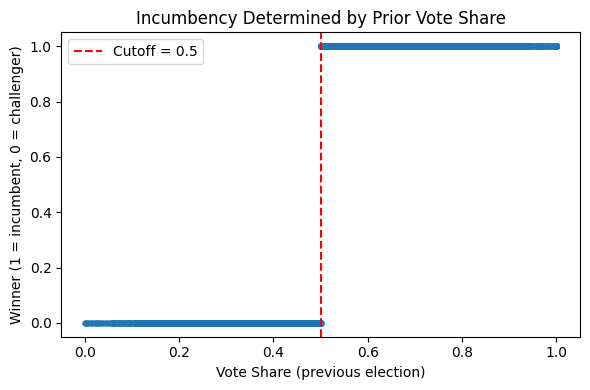

In [4]:
# plot the voteshare and winner
plt.figure(figsize=(6,4))
plt.scatter(df["voteshare"], df["winner"], alpha=0.4, s=12)
plt.axvline(0.5, color="red", linestyle="--", label="Cutoff = 0.5")
plt.xlabel("Vote Share (previous election)")
plt.ylabel("Winner (1 = incumbent, 0 = challenger)")
plt.title("Incumbency Determined by Prior Vote Share")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation of the Plot**

- Each point is one election observation.
- **x-axis:** the candidate’s vote share *in the previous election*.
- **y-axis:** whether the candidate won that previous election  
  (`1 = winner → becomes incumbent`, `0 = loser → challenger`).
- The **red dashed line at 0.5** marks the legal cutoff: candidates with more than 50% become incumbents.
- Notice the sharp jump from 0 to 1 at 0.5 — this reflects the *deterministic assignment rule* that defines treatment in a sharp RDD.
- This plot does **not** show the treatment effect; it only visualizes **how treatment (incumbency) is assigned**.


## Smoothness Test:

\begin{align}
E_U[Y(S=1, U) \mid R=r] \\
E_U[Y(S=0, U) \mid R=r]
\end{align}
are smooth around the cutoff.

We have a multivariate variable $U$, we would like to test if $U$ is smooth around the cutoff, it is hard to test as we do not know the distribution of $U$, but we can **test the components of $U$ separately.**

NOTE: we make strong assumptions, the components of $U$ are smooth does not imply $U$ is smooth, just a weak version of the Smoothness Assumption.

### Margin Variable

To study incumbency using a Regression Discontinuity Design (RDD), we recenter the running variable (previous vote share) around the cutoff of 0.5.

We define:

$$
\text{margin} = \text{voteshare} - 0.5
$$

This transforms the cutoff into **0**, making interpretation easier:

- **margin > 0** → the candidate won the previous election (became the incumbent)  
- **margin < 0** → the candidate lost the previous election (is not the incumbent)  
- **margin = 0** → exactly tied (rare)

<!-- Plotting the distribution of this margin helps us visually check for **bunching**: there should be no unusual jump or pile-up (“bunching”) of observations exactly at the cutoff. -->

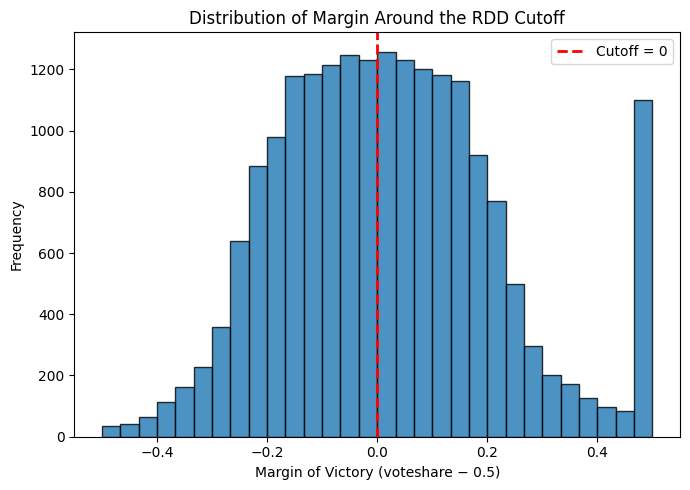

In [5]:
# calcualte the margin of win
df["margin"] = df["voteshare"] - 0.5

plt.figure(figsize=(7,5))
plt.hist(df["margin"], bins=30, edgecolor="black", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Cutoff = 0")
plt.xlabel("Margin of Victory (voteshare − 0.5)")
plt.ylabel("Frequency")
plt.title("Distribution of Margin Around the RDD Cutoff")
plt.legend()
plt.tight_layout()
plt.show()


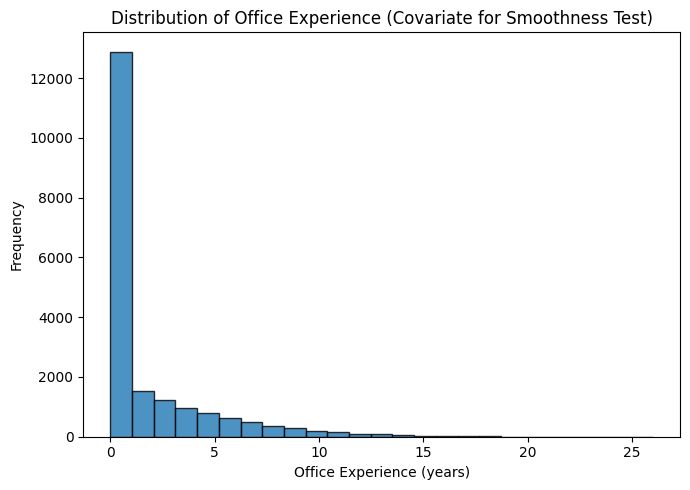

In [7]:
# Covariate 1: Office Experience
# Plot the distribution of office experience to check for smoothness around the cutoff
plt.figure(figsize=(7,5))
plt.hist(df['officeexp'], bins=25, edgecolor="black", alpha=0.8)
plt.xlabel("Office Experience (years)")
plt.ylabel("Frequency")
plt.title("Distribution of Office Experience (Covariate for Smoothness Test)")
plt.tight_layout()
plt.show()

### Smoothness Test: Office Experience vs. Vote Margin

- **Goal:** Check whether observable covariates change *smoothly* at the cutoff (margin = 0).  
- **Why:** If candidates can precisely manipulate the vote margin, or if different types of candidates appear right above vs. right below the cutoff, RDD breaks.
- **Covariate examined:** **`officeexp`** (years of prior office experience), one component of the unobserved variable \( U \).


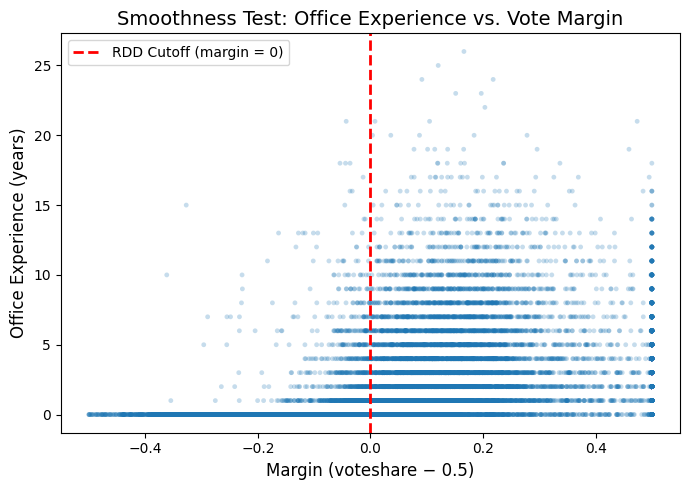

In [8]:
# x axis as margin, y axis as officeexp
plt.figure(figsize=(7,5))

plt.scatter(
    df["margin"], 
    df["officeexp"], 
    alpha=0.25, 
    s=12, 
    edgecolors="none"
)

# Add cutoff line at margin = 0
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="RDD Cutoff (margin = 0)")

plt.xlabel("Margin (voteshare − 0.5)", fontsize=12)
plt.ylabel("Office Experience (years)", fontsize=12)
plt.title("Smoothness Test: Office Experience vs. Vote Margin", fontsize=14)

plt.legend()
plt.tight_layout()
plt.show()


- **Interpretation of plot:**  
  - No visible **jump** in office experience at margin = 0 → suggests no major selection discontinuity.  
  - Office experience gradually increases with margin — but it does not **shift abruptly** at the cutoff.  
  - This pattern is **consistent** with the RDD smoothness assumption.

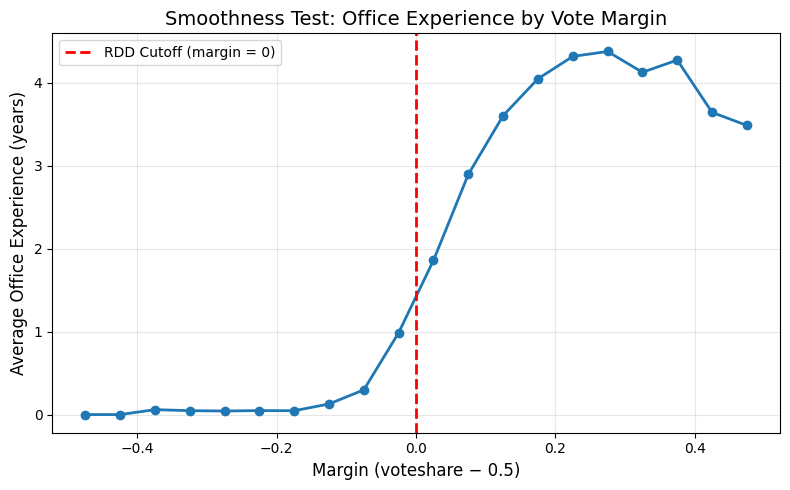

In [9]:
# x axis as margin, y axis as officeexp
# bin size 0.05
import numpy as np

# Bin size
bins = np.arange(-0.5, 0.51, 0.05)

plot_list = []
bin_centers = []

# Compute mean office experience within each bin
for i in range(len(bins)-1):
    lower, upper = bins[i], bins[i+1]
    df_bin = df[df["margin"].between(lower, upper)]
    plot_list.append(df_bin["officeexp"].mean())
    bin_centers.append((lower + upper) / 2)

# Plot
plt.figure(figsize=(8,5))
plt.plot(bin_centers, plot_list, marker="o", markersize=6, linewidth=2, color="#1f77b4")

# Cutoff line at 0
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="RDD Cutoff (margin = 0)")

plt.xlabel("Margin (voteshare − 0.5)", fontsize=12)
plt.ylabel("Average Office Experience (years)", fontsize=12)
plt.title("Smoothness Test: Office Experience by Vote Margin", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Bunching

RDD assumes that candidates cannot precisely manipulate their position around the cutoff. If manipulation occurs, we would observe many more elections that end just above 50% (margin > 0) than just below. This creates "bunching" of the running variable around the cutoff, violating the continuity assumption.

Plotting the distribution of this margin helps us visually check for **bunching**: there should be no unusual jump or pile-up (“bunching”) of observations exactly at the cutoff.


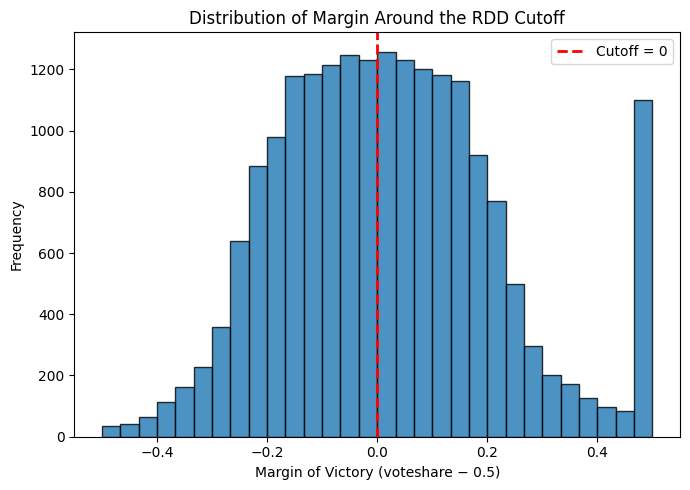

In [6]:
plt.figure(figsize=(7,5))
plt.hist(df["margin"], bins=30, edgecolor="black", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Cutoff = 0")
plt.xlabel("Margin of Victory (voteshare − 0.5)")
plt.ylabel("Frequency")
plt.title("Distribution of Margin Around the RDD Cutoff")
plt.legend()
plt.tight_layout()
plt.show()
